<a href="https://colab.research.google.com/github/beyzaturku/2209/blob/main/yolo_models/yolo11_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
!pip install ultralytics

In [56]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import cv2

In [95]:
from ultralytics import YOLO

def train_yolo():
    model = YOLO("yolo11s.pt")  # Yüklenmiş olmalı (veya yol belirtilmeli)

    results = model.train(
        data='/content/drive/MyDrive/altitude/high_alt_object_detection/dataset/data.yaml',
        epochs=50,
        imgsz=640,
        batch=16,
        project="/content/drive/MyDrive/altitude/high_alt_object_detection/yolo11_train",
        name="yolov11",
        save=True,
        save_period=5
    )
    return model, results

print("1. Model eğitimi başlatılıyor...")
model, results = train_yolo()

1. Model eğitimi başlatılıyor...


100%|██████████| 18.4M/18.4M [00:00<00:00, 153MB/s]


Ultralytics 8.3.156 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/altitude/high_alt_object_detection/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov11, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

train: Scanning /content/drive/MyDrive/altitude/high_alt_object_detection/dataset/labels/train.cache... 281 images, 0 backgrounds, 0 corrupt: 100%|██████████| 281/281 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


...

      50/50      3.94G     0.8874      0.448     0.7909        115        640: 100%|██████████| 18/18 [00:02<00:00,  8.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  8.27it/s]

                   all         71        925      0.977      0.957      0.981      0.814



50 epochs completed in 0.047 hours.
Optimizer stripped from /content/drive/MyDrive/altitude/high_alt_object_detection/yolo11_train/yolov11/weights/last.pt, 19.2MB
Optimizer stripped from /content/drive/MyDrive/altitude/high_alt_object_detection/yolo11_train/yolov11/weights/best.pt, 19.2MB

Validating /content/drive/MyDrive/altitude/high_alt_object_detection/yolo11_train/yolov11/weights/best.pt...
Ultralytics 8.3.156 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLO11s summary (fused): 100 layers, 9,414,348 parameters, 0 gradients, 21.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  3.76it/s]


                   all         71        925      0.977      0.957      0.981      0.815
                   car         71        912      0.972      0.913      0.968      0.707
                   bus         13         13      0.981          1      0.995      0.923
Speed: 0.1ms preprocess, 0.8ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /content/drive/MyDrive/altitude/high_alt_object_detection/yolo11_train/yolov11


In [84]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import cv2

def create_metrics_table(csv_path):
    # CSV dosyasını oku
    df = pd.read_csv(csv_path)

    # Önemli sütunları seç ve yeniden adlandır
    metrics_df = df[['epoch', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
                     'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
                     'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss']].copy()

    # Sütun isimlerini sadeleştir
    metrics_df.columns = ['Epoch', 'Train_Box_Loss', 'Train_Cls_Loss', 'Train_DFL_Loss',
                         'Precision', 'Recall', 'mAP50', 'mAP50_95',
                         'Val_Box_Loss', 'Val_Cls_Loss', 'Val_DFL_Loss']

    print("Model Performans Metrikleri:")
    print(metrics_df.tail(10))  # Son 10 epoch
    return metrics_df

def visualize_results(df):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Loss grafikleri (Train vs Val)
    axes[0,0].plot(df['Epoch'], df['Train_Box_Loss'], label='Train Box Loss', color='blue')
    axes[0,0].plot(df['Epoch'], df['Val_Box_Loss'], label='Val Box Loss', color='red')
    axes[0,0].set_title('Box Loss Eğrileri')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Loss')
    axes[0,0].legend()
    axes[0,0].grid(True)

    # mAP grafikleri
    axes[0,1].plot(df['Epoch'], df['mAP50'], label='mAP50', color='green')
    axes[0,1].plot(df['Epoch'], df['mAP50_95'], label='mAP50-95', color='orange')
    axes[0,1].set_title('mAP Metrikleri')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('mAP')
    axes[0,1].legend()
    axes[0,1].grid(True)

    # Precision ve Recall
    axes[1,0].plot(df['Epoch'], df['Precision'], label='Precision', color='purple')
    axes[1,0].plot(df['Epoch'], df['Recall'], label='Recall', color='brown')
    axes[1,0].set_title('Precision & Recall')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('Değer')
    axes[1,0].legend()
    axes[1,0].grid(True)

    # Tüm Loss türleri
    axes[1,1].plot(df['Epoch'], df['Train_Box_Loss'], label='Box Loss')
    axes[1,1].plot(df['Epoch'], df['Train_Cls_Loss'], label='Cls Loss')
    axes[1,1].plot(df['Epoch'], df['Train_DFL_Loss'], label='DFL Loss')
    axes[1,1].set_title('Eğitim Loss Türleri')
    axes[1,1].set_xlabel('Epoch')
    axes[1,1].set_ylabel('Loss')
    axes[1,1].legend()
    axes[1,1].grid(True)

    plt.tight_layout()
    plt.show()

    # Son epoch özet tablosu
    final_metrics = df.iloc[-1]
    print(f"\nFinal Epoch ({int(final_metrics['Epoch'])}) Sonuçları:")
    print(f"mAP50: {final_metrics['mAP50']:.4f}")
    print(f"mAP50-95: {final_metrics['mAP50_95']:.4f}")
    print(f"Precision: {final_metrics['Precision']:.4f}")
    print(f"Recall: {final_metrics['Recall']:.4f}")

def test_single_image(model_path, image_path, conf_threshold=0.25, iou_threshold=0.45):
    model = YOLO(model_path)

    # Düşük threshold ile tahmin (daha fazla tespit için)
    results = model(image_path, conf=conf_threshold, iou=iou_threshold)

    # Görselleştirme
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Sonuçları çiz
    annotated_img = results[0].plot()

    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_img)
    plt.title(f'YOLO Tespiti (conf≥{conf_threshold}, iou≥{iou_threshold}) - {len(results[0].boxes) if results[0].boxes is not None else 0} nesne bulundu')
    plt.axis('off')
    plt.show()

    # Detay bilgiler
    if results[0].boxes is not None:
        print(f"\nToplam {len(results[0].boxes)} nesne tespit edildi:")
        print("-" * 40)
        for i, box in enumerate(results[0].boxes):
            conf = box.conf.item()
            cls = int(box.cls.item())
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            print(f"Nesne {i+1}: Sınıf {cls}, Güven: {conf:.3f}, Box: [{x1:.0f},{y1:.0f},{x2:.0f},{y2:.0f}]")
    else:
        print("Hiç nesne tespit edilmedi!")

    return results

def compare_thresholds(model_path, image_path):
    """Farklı confidence ve IOU threshold'larını karşılaştır"""
    thresholds = [
        (0.5, 0.5),   # Varsayılan (yüksek)
        (0.3, 0.4),   # Orta
        (0.1, 0.3)    # Düşük (daha hassas)
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for i, (conf, iou) in enumerate(thresholds):
        model = YOLO(model_path)
        results = model(image_path, conf=conf, iou=iou)

        annotated_img = results[0].plot()

        axes[i].imshow(annotated_img)
        axes[i].set_title(f'conf={conf}, iou={iou}\n{len(results[0].boxes) if results[0].boxes is not None else 0} tespit')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()


2. CSV'den metrikler okunuyor...
Model Performans Metrikleri:
    Epoch  Train_Box_Loss  Train_Cls_Loss  Train_DFL_Loss  Precision   Recall  \
40     41         1.06459         0.52056         0.80017    0.97471  0.96125   
41     42         0.99589         0.49192         0.80250    0.96338  0.95618   
42     43         0.98067         0.48473         0.79645    0.96606  0.92750   
43     44         0.97819         0.48546         0.79298    0.97128  0.94603   
44     45         0.97360         0.47715         0.80193    0.96408  0.94913   
45     46         0.94990         0.46697         0.80145    0.96734  0.94772   
46     47         0.96001         0.46957         0.80211    0.96926  0.95772   
47     48         0.92384         0.45611         0.79453    0.98154  0.95842   
48     49         0.92503         0.46180         0.79254    0.97180  0.95720   
49     50         0.88744         0.44795         0.79093    0.97726  0.95669   

      mAP50  mAP50_95  Val_Box_Loss  Val_Cls_

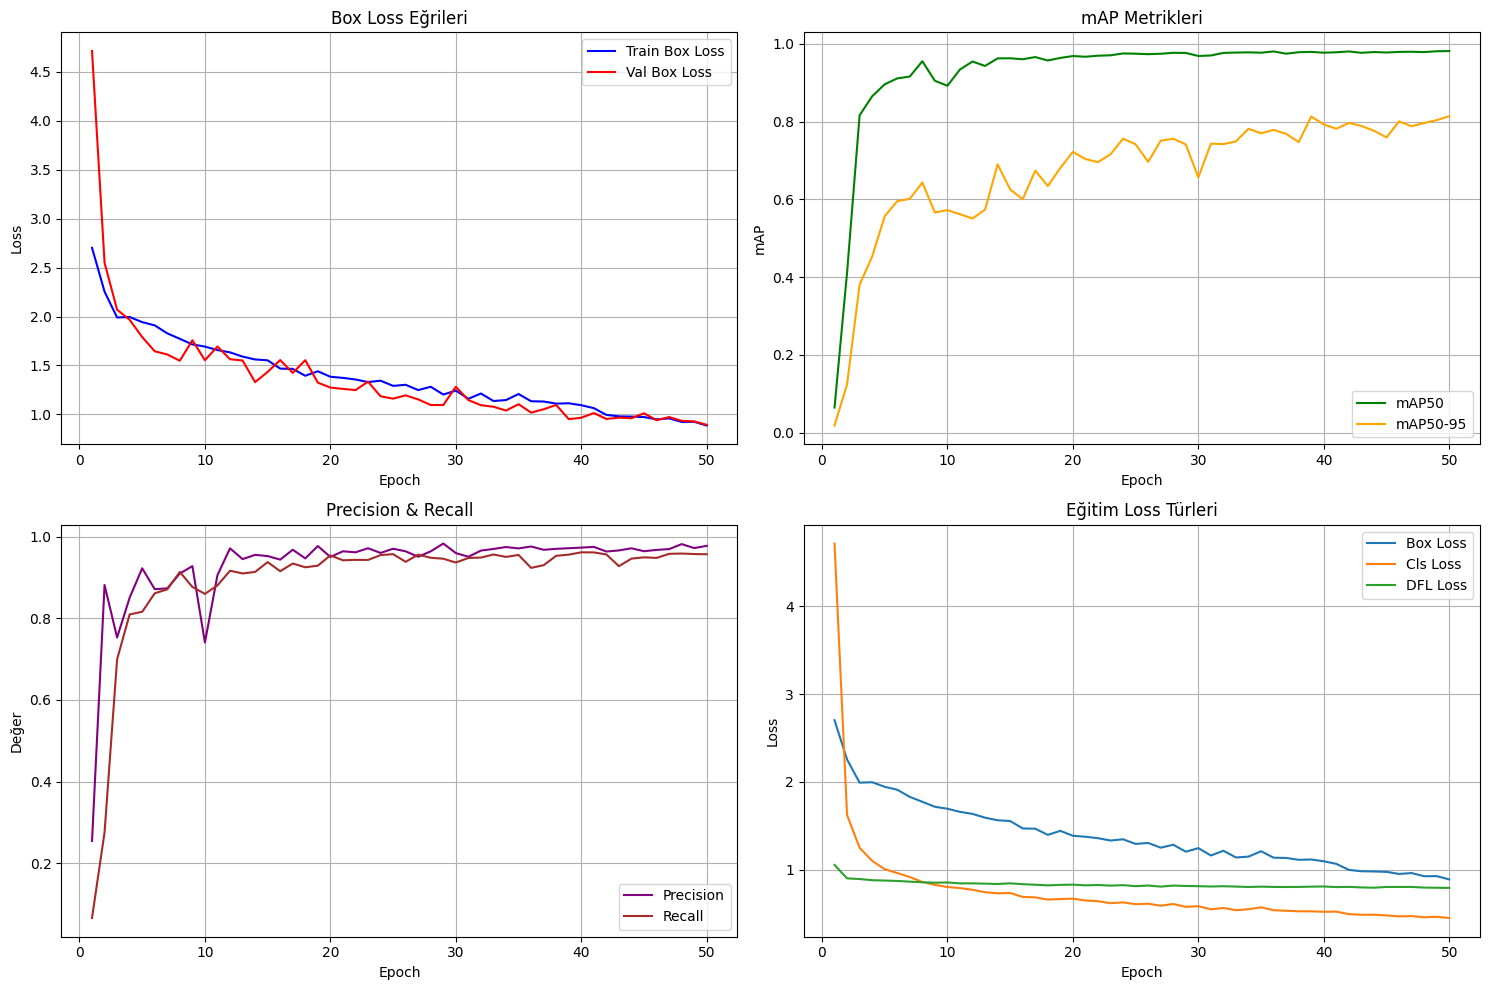


Final Epoch (50) Sonuçları:
mAP50: 0.9815
mAP50-95: 0.8141
Precision: 0.9773
Recall: 0.9567

4. Tek görsel test ediliyor...

image 1/1 /content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg: 352x640 8 cars, 25.7ms
Speed: 2.2ms preprocess, 25.7ms inference, 1.7ms postprocess per image at shape (1, 3, 352, 640)


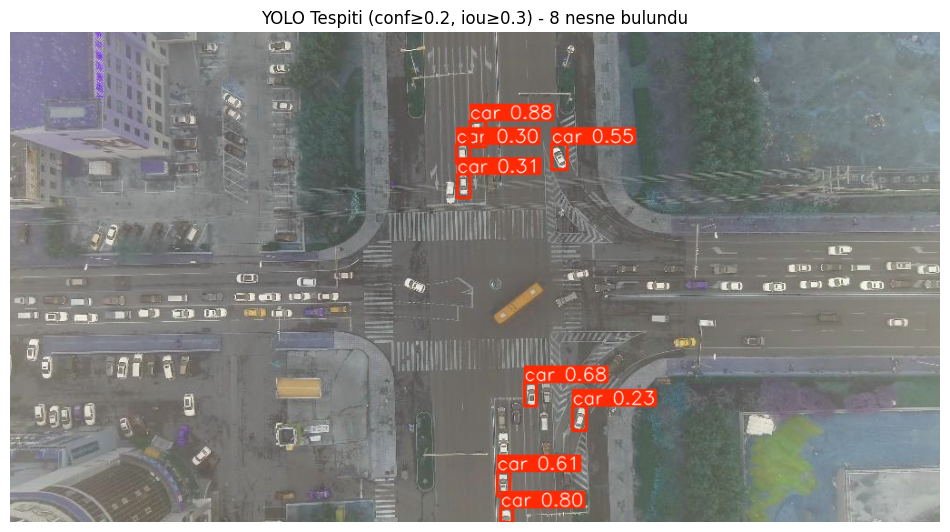


Toplam 8 nesne tespit edildi:
----------------------------------------
Nesne 1: Sınıf 0, Güven: 0.878, Box: [507,99,523,128]
Nesne 2: Sınıf 0, Güven: 0.796, Box: [541,524,554,540]
Nesne 3: Sınıf 0, Güven: 0.683, Box: [567,386,579,412]
Nesne 4: Sınıf 0, Güven: 0.612, Box: [537,485,551,512]
Nesne 5: Sınıf 0, Güven: 0.550, Box: [597,125,614,153]
Nesne 6: Sınıf 0, Güven: 0.310, Box: [493,158,506,184]
Nesne 7: Sınıf 0, Güven: 0.296, Box: [492,124,507,146]
Nesne 8: Sınıf 0, Güven: 0.229, Box: [619,412,635,440]

4. Farklı threshold'lar karşılaştırılıyor...

image 1/1 /content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg: 352x640 5 cars, 11.6ms
Speed: 2.2ms preprocess, 11.6ms inference, 1.7ms postprocess per image at shape (1, 3, 352, 640)

image 1/1 /content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg: 352x640 6 cars, 12.1ms
Speed: 2.2ms preprocess, 12.1ms inference, 1.9ms postprocess p

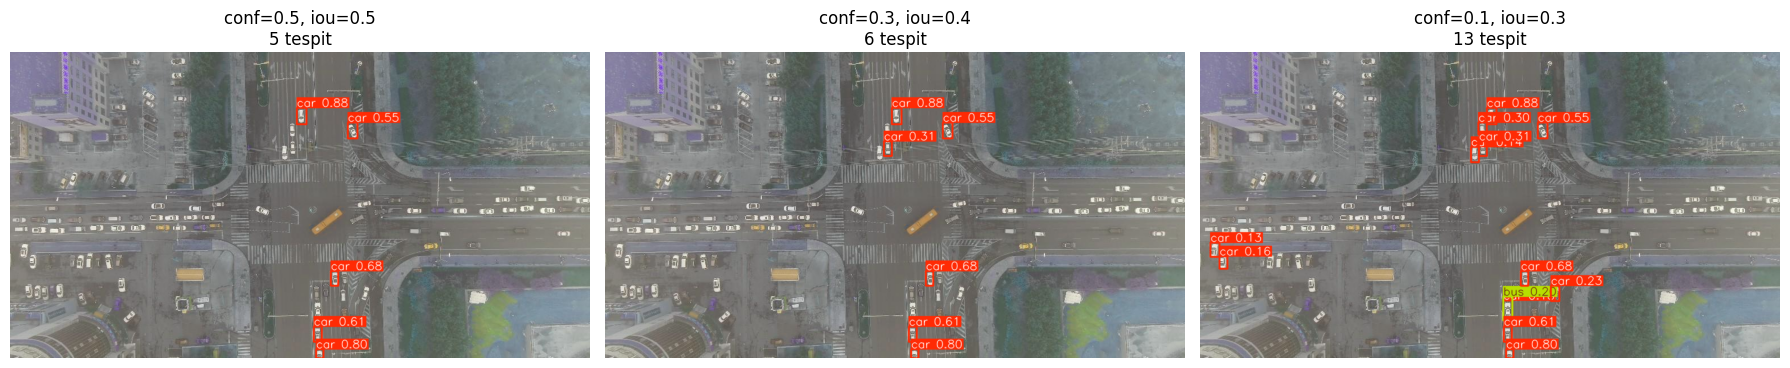

In [96]:
print("\n2. CSV'den metrikler okunuyor...")
df = create_metrics_table('/content/drive/MyDrive/altitude/high_alt_object_detection/yolo11_train/yolov11/results.csv')

    # Görselleştir
print("\n3. Sonuçlar görselleştiriliyor...")
visualize_results(df)

    # Test et
print("\n4. Tek görsel test ediliyor...")
test_single_image('/content/drive/MyDrive/altitude/high_alt_object_detection/yolo11_train/yolov11/weights/best.pt', '/content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg', conf_threshold=0.2, iou_threshold=0.3)

print("\n4. Farklı threshold'lar karşılaştırılıyor...")
compare_thresholds('/content/drive/MyDrive/altitude/high_alt_object_detection/yolo11_train/yolov11/weights/best.pt', '/content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg')


image 1/1 /content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg: 352x640 12 cars, 1 bus, 11.4ms
Speed: 1.9ms preprocess, 11.4ms inference, 1.6ms postprocess per image at shape (1, 3, 352, 640)


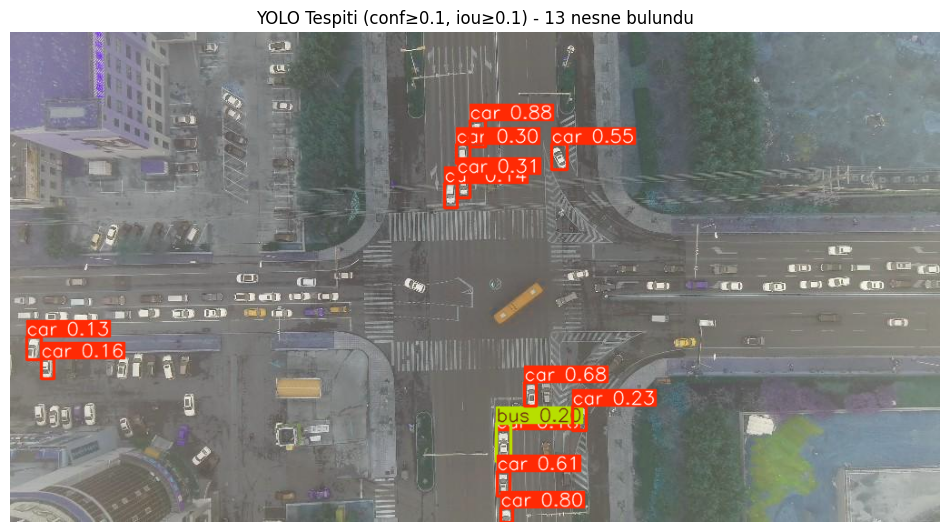


Toplam 13 nesne tespit edildi:
----------------------------------------
Nesne 1: Sınıf 0, Güven: 0.878, Box: [507,99,523,128]
Nesne 2: Sınıf 0, Güven: 0.796, Box: [541,524,554,540]
Nesne 3: Sınıf 0, Güven: 0.683, Box: [567,386,579,412]
Nesne 4: Sınıf 0, Güven: 0.612, Box: [537,485,551,512]
Nesne 5: Sınıf 0, Güven: 0.550, Box: [597,125,614,153]
Nesne 6: Sınıf 0, Güven: 0.310, Box: [493,158,506,184]
Nesne 7: Sınıf 0, Güven: 0.296, Box: [492,124,507,146]
Nesne 8: Sınıf 0, Güven: 0.229, Box: [619,412,635,440]
Nesne 9: Sınıf 3, Güven: 0.197, Box: [536,432,551,474]
Nesne 10: Sınıf 0, Güven: 0.177, Box: [536,439,551,473]
Nesne 11: Sınıf 0, Güven: 0.158, Box: [34,361,49,383]
Nesne 12: Sınıf 0, Güven: 0.144, Box: [479,168,492,194]
Nesne 13: Sınıf 0, Güven: 0.131, Box: [19,336,34,362]


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'car', 1: 'vehicle', 2: 'truck', 3: 'bus'}
 obb: None
 orig_img: array([[[130, 124, 155],
         [130, 124, 155],
         [131, 125, 156],
         ...,
         [130, 146, 158],
         [136, 152, 164],
         [142, 158, 170]],
 
        [[133, 127, 158],
         [133, 127, 158],
         [133, 127, 158],
         ...,
         [132, 148, 160],
         [136, 152, 164],
         [139, 155, 167]],
 
        [[136, 130, 161],
         [136, 130, 161],
         [135, 129, 160],
         ...,
         [134, 150, 162],
         [135, 151, 163],
         [136, 152, 164]],
 
        ...,
 
        [[139, 136, 131],
         [137, 134, 129],
         [134, 131, 126],
         ...,
         [134, 139, 130],
         [133, 138, 129],
         [133, 138, 129]],
 
        [[139, 136, 132],
         [136, 133, 129],
         [132, 129, 125],

In [97]:
test_single_image('/content/drive/MyDrive/altitude/high_alt_object_detection/yolo11_train/yolov11/weights/best.pt', '/content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg', conf_threshold=0.1, iou_threshold=0.1)


image 1/1 /content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg: 352x640 51 cars, 4 buss, 12.6ms
Speed: 2.2ms preprocess, 12.6ms inference, 1.7ms postprocess per image at shape (1, 3, 352, 640)


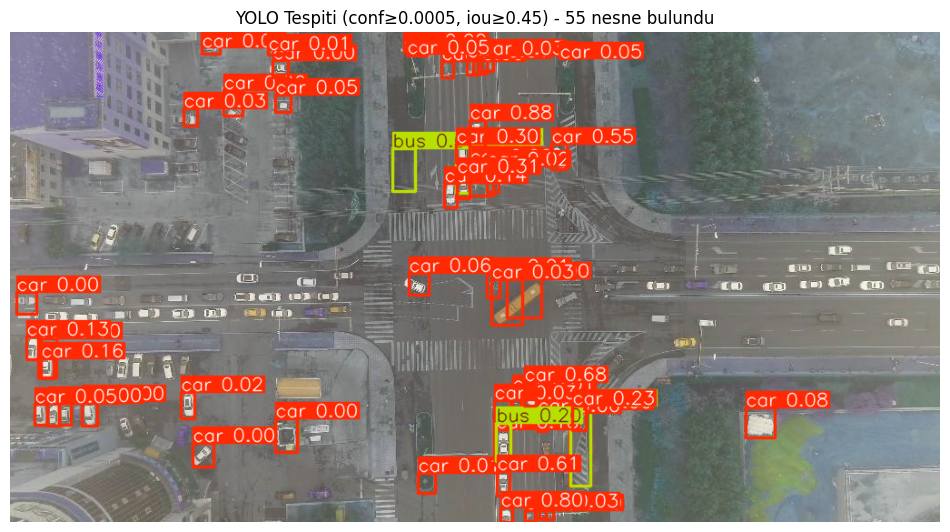


Toplam 55 nesne tespit edildi:
----------------------------------------
Nesne 1: Sınıf 0, Güven: 0.878, Box: [507,99,523,128]
Nesne 2: Sınıf 0, Güven: 0.796, Box: [541,524,554,540]
Nesne 3: Sınıf 0, Güven: 0.683, Box: [567,386,579,412]
Nesne 4: Sınıf 0, Güven: 0.612, Box: [537,485,551,512]
Nesne 5: Sınıf 0, Güven: 0.550, Box: [597,125,614,153]
Nesne 6: Sınıf 0, Güven: 0.310, Box: [493,158,506,184]
Nesne 7: Sınıf 0, Güven: 0.296, Box: [492,124,507,146]
Nesne 8: Sınıf 0, Güven: 0.229, Box: [619,412,635,440]
Nesne 9: Sınıf 3, Güven: 0.197, Box: [536,432,551,474]
Nesne 10: Sınıf 0, Güven: 0.177, Box: [536,439,551,473]
Nesne 11: Sınıf 0, Güven: 0.158, Box: [34,361,49,383]
Nesne 12: Sınıf 0, Güven: 0.144, Box: [479,168,492,194]
Nesne 13: Sınıf 0, Güven: 0.131, Box: [19,336,34,362]
Nesne 14: Sınıf 0, Güven: 0.077, Box: [810,414,843,448]
Nesne 15: Sınıf 0, Güven: 0.063, Box: [439,266,461,291]
Nesne 16: Sınıf 0, Güven: 0.054, Box: [27,410,42,433]
Nesne 17: Sınıf 0, Güven: 0.051, Box: [293,71,3

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'car', 1: 'vehicle', 2: 'truck', 3: 'bus'}
 obb: None
 orig_img: array([[[130, 124, 155],
         [130, 124, 155],
         [131, 125, 156],
         ...,
         [130, 146, 158],
         [136, 152, 164],
         [142, 158, 170]],
 
        [[133, 127, 158],
         [133, 127, 158],
         [133, 127, 158],
         ...,
         [132, 148, 160],
         [136, 152, 164],
         [139, 155, 167]],
 
        [[136, 130, 161],
         [136, 130, 161],
         [135, 129, 160],
         ...,
         [134, 150, 162],
         [135, 151, 163],
         [136, 152, 164]],
 
        ...,
 
        [[139, 136, 131],
         [137, 134, 129],
         [134, 131, 126],
         ...,
         [134, 139, 130],
         [133, 138, 129],
         [133, 138, 129]],
 
        [[139, 136, 132],
         [136, 133, 129],
         [132, 129, 125],

In [98]:
test_single_image('/content/drive/MyDrive/altitude/high_alt_object_detection/yolo11_train/yolov11/weights/best.pt', '/content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg', conf_threshold=0.0005)